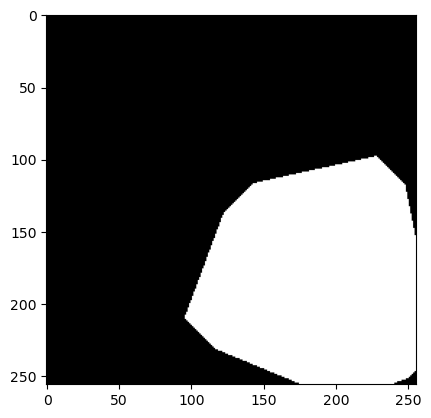

In [156]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread("images/spot.png", cv2.IMREAD_GRAYSCALE)

image = image.astype(np.uint16)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

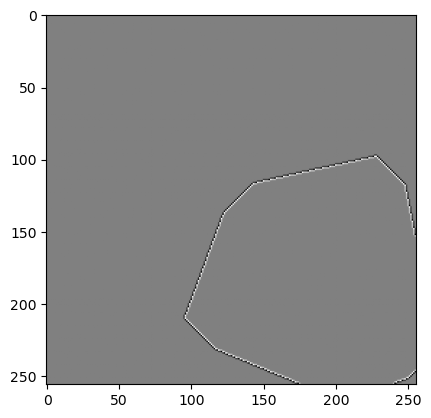

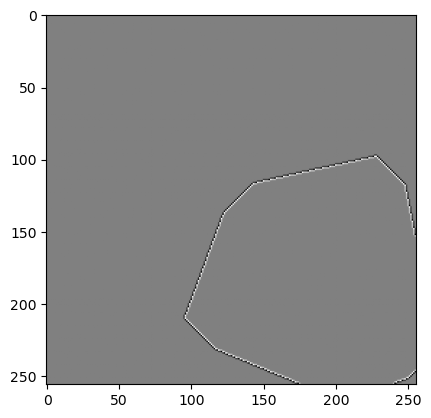

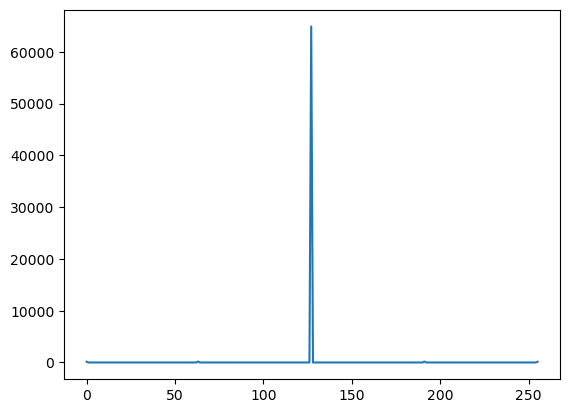

In [157]:
# Filtro Laplaciano

#Aplique un filtro Laplaciano. Visualice el resultado ****(puede efectuar una calibración del histograma -entre 0 y 255- de la imagen obtenida para visualizar mejor los detalles de la imagen del Laplaciano).

from skimage.filters import laplace
from skimage import exposure

img_l = laplace(image, ksize=3)

# Visualizar imagen
plt.imshow(img_l, cmap="gray")
plt.show()

# Visualizar histograma
#Calibracion del histograma
rescaled_img = exposure.rescale_intensity(img_l, in_range=(img_l.min(),img_l.max()), out_range=(0,255))

# Visualizar imagen
plt.imshow(rescaled_img, cmap="gray")
plt.show()

# Visualizar histograma
rescaled_img = rescaled_img.astype(np.uint8)
hist = cv2.calcHist([rescaled_img],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

¿Cómo es la respuesta del Laplaciano en las regiones homogéneas de la imagen y en los contornos? ¿A qué se debe este resultado?

En las regiones homogeneas, la derivada nos da 0, no hay cambios bruscos de intensidad, por lo tanto el valor es 0. Pero en los contornos, es donde hay cambios bruscos y los valores pasan por 0, es decir, cambian de signo, porque pasan por cero, por eso se puede evidenciar que el borde es blanco y negro.

Operador LoG (Laplacian of Gaussian):
Ahora vamos a efectuar un filtrado gaussiano previo al cálculo del Laplaciano, lo cual es equivalente a aplicar el operador LoG (Laplacian of Gaussian) a la imagen original.

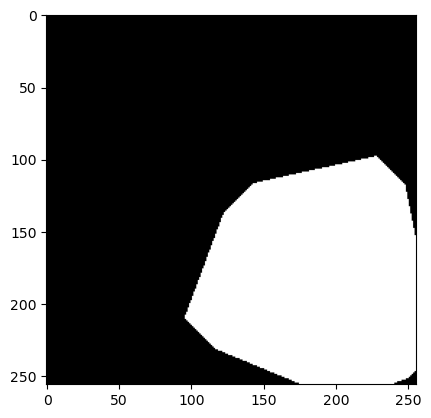

In [158]:
# Aplique un filtro Gaussiano con varianza en 0 a la imagen. Visualice el resultado.
from skimage.filters import gaussian

img_gaus = gaussian(image, sigma=0, preserve_range=True)

# Visualizar imagen
plt.imshow(img_gaus, cmap="gray")
plt.show()

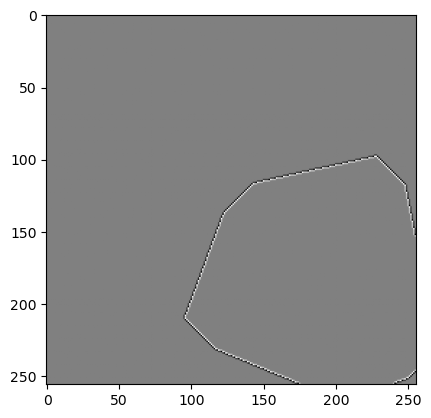

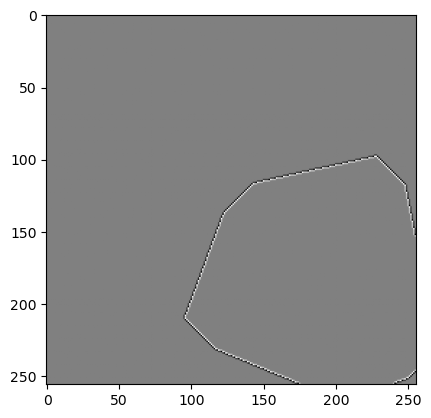

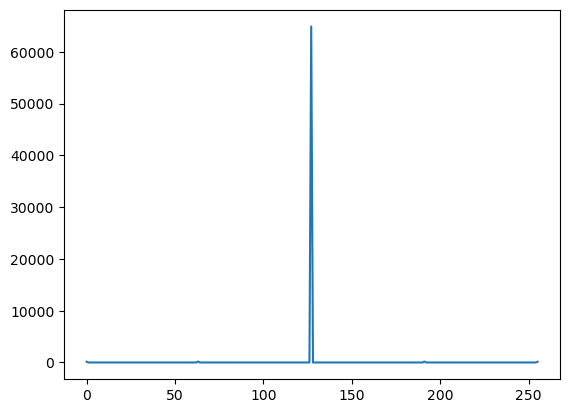

In [159]:
#Aplique sobre el resutlado del paso anterior un filtro Laplaciano.
# Visualice el resultado ****(puede efectuar una calibración del histograma -entre 0 y 255- de la imagen obtenida para visualizar mejor los detalles de la imagen del Laplaciano). 

img_l = laplace(img_gaus, ksize=3)

# Visualizar imagen
plt.imshow(img_l, cmap="gray")
plt.show()

# Visualizar histograma
#Calibracion del histograma
rescaled_img = exposure.rescale_intensity(img_l, in_range=(img_l.min(),img_l.max()), out_range=(0,255))

# Visualizar imagen
plt.imshow(rescaled_img, cmap="gray")
plt.show()

# Visualizar histograma
rescaled_img = rescaled_img.astype(np.uint8)
hist = cv2.calcHist([rescaled_img],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

¿Cómo es la respuesta de este LoG con respecto al Laplaciano sin filtrado previo del ejercicio anterior? ¿A qué se debe este resultado?

El histograma cambia porque, sin aplicar previamente el filtro Gaussiano, el Laplaciano actúa directamente sobre la imagen original y solo detecta variaciones muy locales de intensidad; como la imagen es relativamente limpia, los valores obtenidos no son extremos y permanecen concentrados cerca de cero. En cambio, cuando se aplica un suavizado Gaussiano antes del Laplaciano, las transiciones de intensidad se expanden y los bordes se vuelven más anchos, lo que provoca que la segunda derivada genere valores de mayor magnitud y, por tanto, una distribución más amplia en el histograma. Tambien hay que considerar que el valor de sigma es 0, por lo que el filtro no tiene tanto efecto.

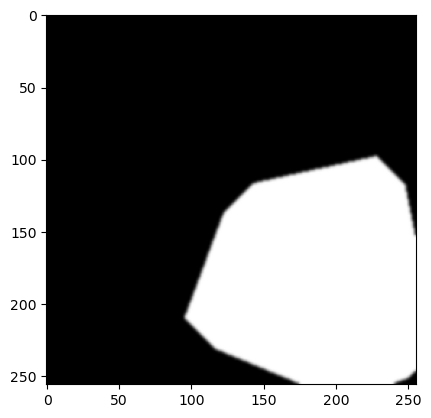

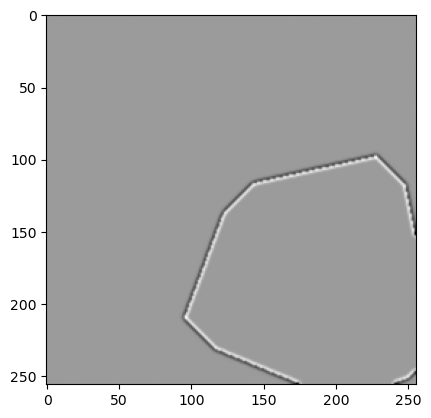

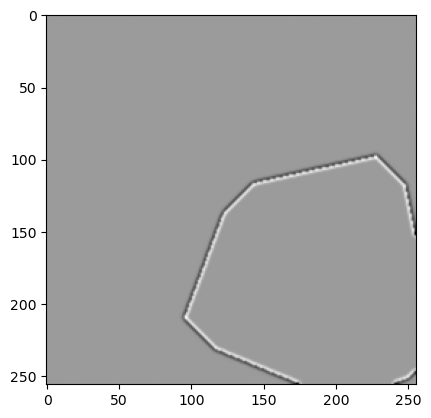

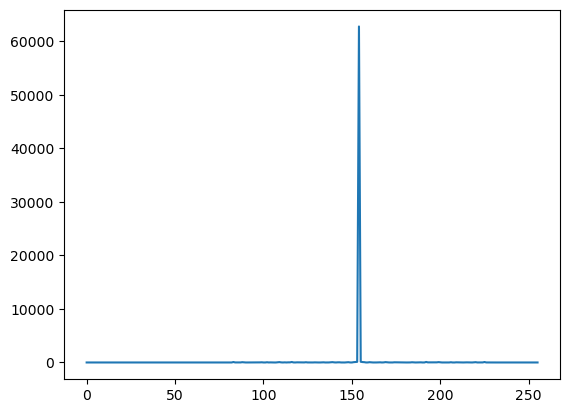

In [160]:
#Repita los pasos 5 y 6, pero cambiando a 1 el valor de la varianza en el filtro gaussiano. ¿Cómo es la respuesta de este LoG con respecto al Laplaciano sin filtrado previo del ejercicio anterior? ¿A qué se debe este resultado?

from skimage.filters import gaussian

img_gaus = gaussian(image, sigma=1, preserve_range=True)

# Visualizar imagen
plt.imshow(img_gaus, cmap="gray")
plt.show()

img_l = laplace(img_gaus, ksize=3)

# Visualizar imagen
plt.imshow(img_l, cmap="gray")
plt.show()

# Visualizar histograma
#Calibracion del histograma
rescaled_img = exposure.rescale_intensity(img_l, in_range=(img_l.min(),img_l.max()), out_range=(0,255))

# Visualizar imagen
plt.imshow(rescaled_img, cmap="gray")
plt.show()

# Visualizar histograma
rescaled_img = rescaled_img.astype(np.uint8)
hist = cv2.calcHist([rescaled_img],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()


Al aplicar el filtro LoG con sigma=1, la respuesta es muy similar al Laplaciano sin filtrado previo, pero se observa un leve cambio en los bordes: estos aparecen ligeramente más suavizados y menos definidos.
Esto ocurre porque el filtro gaussiano con sigma=1 introduce un pequeño suavizado, que reduce mínimamente el contraste en los contornos.

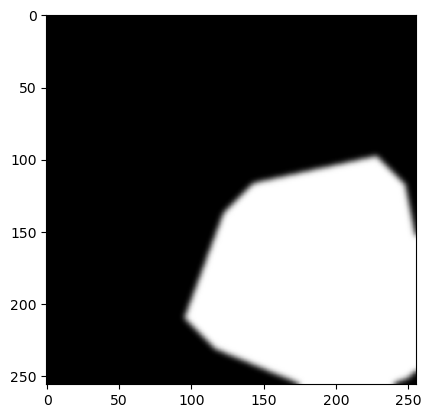

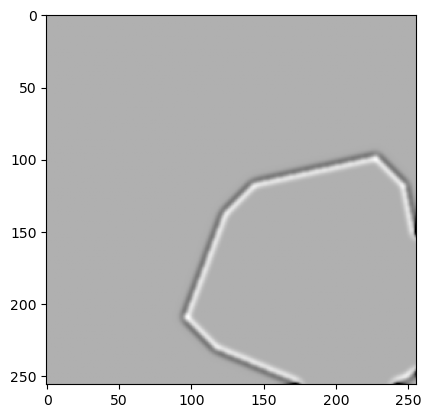

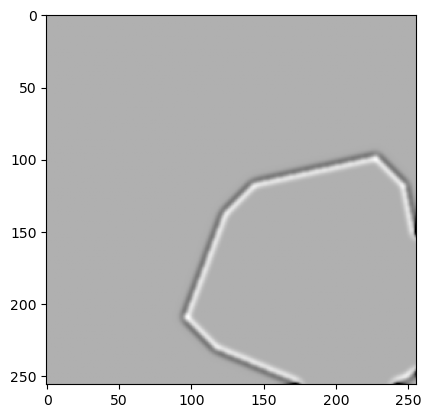

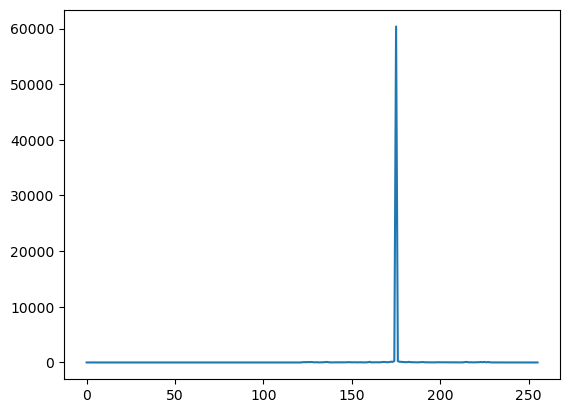

In [161]:
#Repita los pasos 5 y 6, pero cambiando a 2 el valor de la varianza en el filtro gaussiano. ¿Cómo es la respuesta de este LoG con respecto al Laplaciano sin filtrado previo del ejercicio anterior? ¿A qué se debe este resultado?

from skimage.filters import gaussian

img_gaus = gaussian(image, sigma=2, preserve_range=True)

# Visualizar imagen
plt.imshow(img_gaus, cmap="gray")
plt.show()

img_l = laplace(img_gaus, ksize=3)

# Visualizar imagen
plt.imshow(img_l, cmap="gray")
plt.show()

# Visualizar histograma
#Calibracion del histograma
rescaled_img = exposure.rescale_intensity(img_l, in_range=(img_l.min(),img_l.max()), out_range=(0,255))

# Visualizar imagen
plt.imshow(rescaled_img, cmap="gray")
plt.show()

# Visualizar histograma
rescaled_img = rescaled_img.astype(np.uint8)
hist = cv2.calcHist([rescaled_img],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

Al aplicar el filtro LoG con sigma=2, el suavizado es mucho más notorio. Los bordes se ven más anchos y menos definidos, y el contraste en los contornos disminuye.
Esto ocurre porque el filtro gaussiano elimina más detalles y difumina los bordes, haciendo que pierdan nitidez. Las zonas homogéneas siguen igual, pero los contornos se ven más suaves y menos marcados.

Comparación entre Sobel y LoG

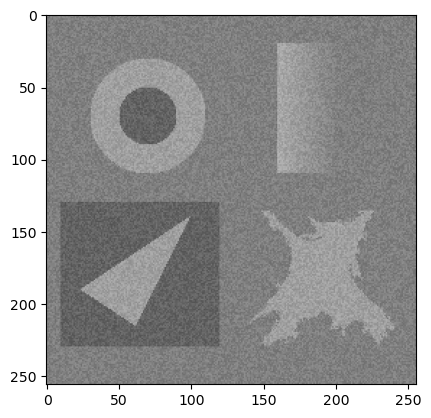

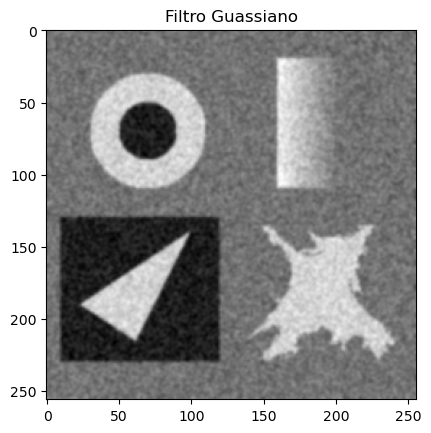

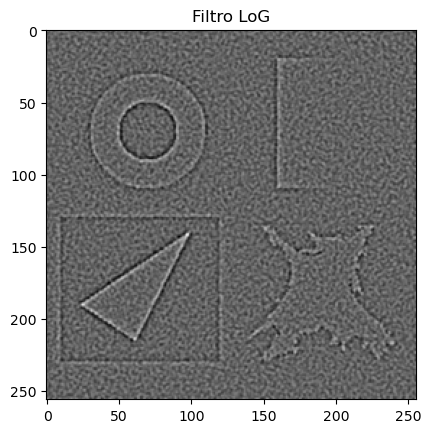

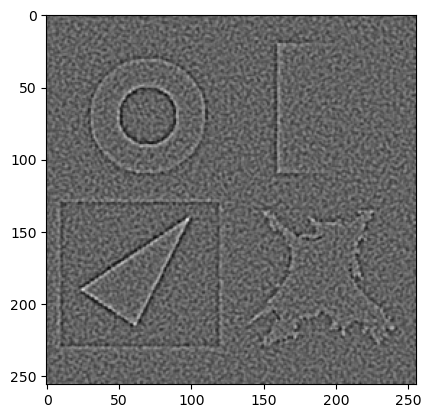

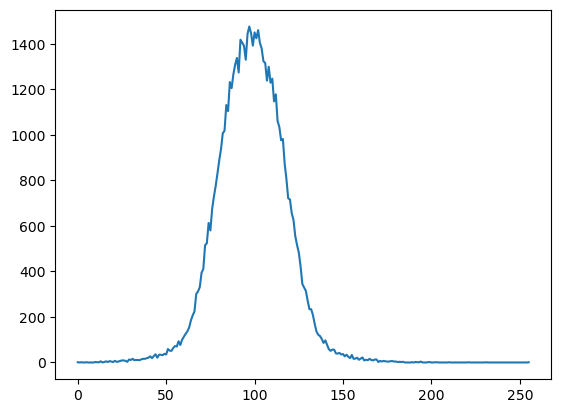

In [162]:
#Cargue la imagen bruit y visualícela. Aplique un filtro gaussiano (con varianza igual a 1) y un filtro Laplaciano siguiendo los mismos pasos de los ejercicios previos. Visualice la imagen del LoG.

image = cv2.imread("images/bruit.png", cv2.IMREAD_GRAYSCALE)

image = image.astype(np.uint16)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

img_gaus = gaussian(image, sigma=1, preserve_range=True)

# Visualizar imagen
plt.imshow(img_gaus, cmap="gray")
plt.title("Filtro Guassiano")
plt.show()

img_l = laplace(img_gaus, ksize=3)

# Visualizar imagen
plt.imshow(img_l, cmap="gray")
plt.title("Filtro LoG")
plt.show()

# Visualizar histograma
#Calibracion del histograma
rescaled_img = exposure.rescale_intensity(img_l, in_range=(img_l.min(),img_l.max()), out_range=(0,255))

# Visualizar imagen
plt.imshow(rescaled_img, cmap="gray")
plt.show()

# Visualizar histograma
rescaled_img = rescaled_img.astype(np.uint8)
hist = cv2.calcHist([rescaled_img],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

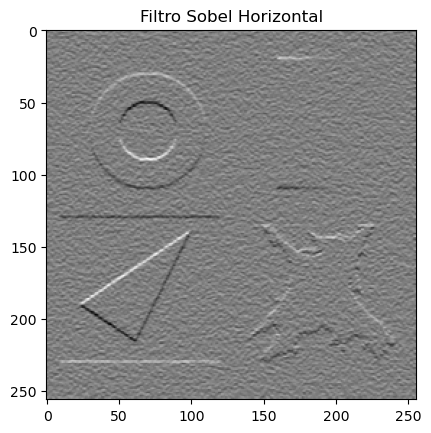

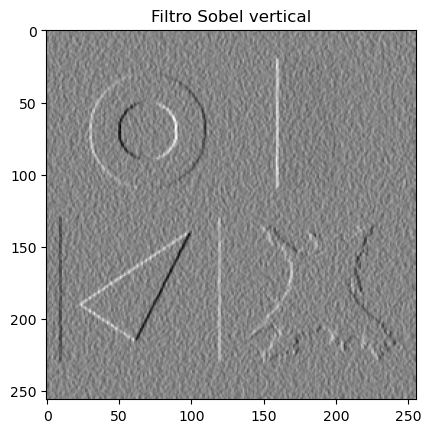

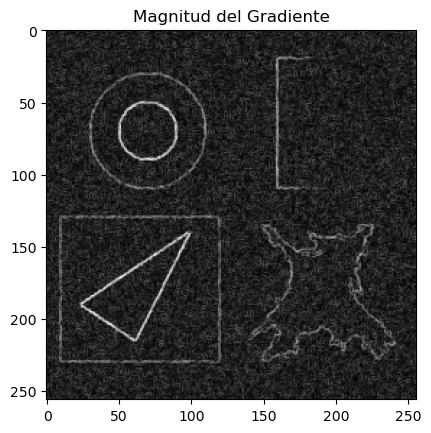

0.0 0.0013125087399706561


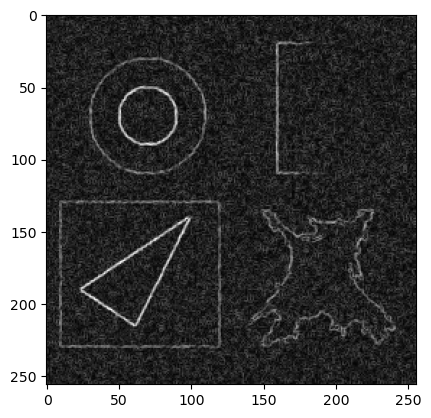

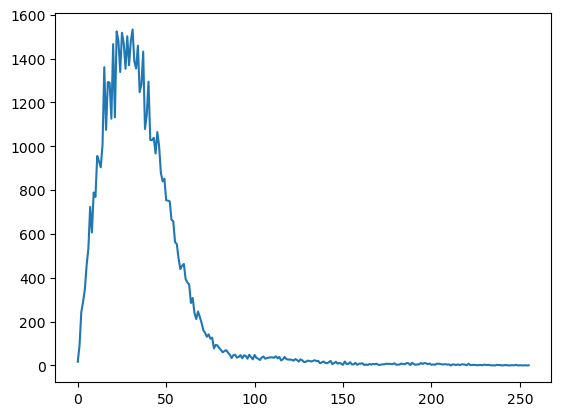

In [163]:
#Calcule sobre la misma imagen bruit la norma del gradiente utilizando el operador de Sobel. Para una mejor visualización, calibre el histograma de las imágenes resultantes. 
from skimage.filters import sobel_h, sobel_v, sobel
from skimage import exposure

#Aplica el filtro Sobel horizontal
img_sh = sobel_h(image)
# Visualizar imagen
plt.imshow(img_sh, cmap="gray")
plt.title("Filtro Sobel Horizontal")
plt.show()

#--- Aplique un filtro de Sobel vertical sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección X ). Visualice los resultados.
#Aplica el filtro Sobel vertical
img_sv = sobel_v(image)
# Visualizar imagen
plt.imshow(img_sv, cmap="gray")
plt.title("Filtro Sobel vertical")
plt.show()

# Calcule la norma (magnitud) del gradiente de acuerdo con la definición a partir de las dos imágenes resultantes anteriores. Visualice los resultados.
# Magnitud del gradiente
gradiente_sobel = np.sqrt(img_sh**2 + img_sv**2)

# Visualizar
plt.imshow(gradiente_sobel, cmap="gray")
plt.title("Magnitud del Gradiente")
plt.show()

print(gradiente_sobel.min(), gradiente_sobel.max())
#Calibracion del histograma
rescaled_img = exposure.rescale_intensity(gradiente_sobel, in_range=(gradiente_sobel.min(),gradiente_sobel.max()), out_range=(0,255))

# Visualizar imagen
plt.imshow(rescaled_img, cmap="gray")
plt.show()

# Visualizar histograma
rescaled_img = rescaled_img.astype(np.uint8)
hist = cv2.calcHist([rescaled_img],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()



¿En cuál de las dos imágenes es más fácil detectar los contornos. ¿Por qué ? ¿Cómo afecta el ruido la detección de los contornos en cada caso?

Es más fácil detectar los contornos en la imagen obtenida con la magnitud del gradiente de Sobel. En esa imagen los bordes aparecen como líneas brillantes bien definidas y continuas sobre un fondo más oscuro, ya que el gradiente mide la primera derivada y resalta directamente las zonas donde hay cambios bruscos de intensidad. En cambio, en la imagen del Laplaciano (LoG) los bordes aparecen como pares de líneas claras y oscuras debido a que se trata de una segunda derivada, lo que hace que el contorno real corresponda al cruce por cero entre ambas respuestas esto dificulta su detección visual.

En cuanto al ruido, el Laplaciano es más sensible porque las segundas derivadas amplifican las variaciones pequeñas de intensidad. Aunque el uso previo del filtro Gaussiano reduce este efecto, el LoG sigue siendo más susceptible al ruido que Sobel. El gradiente de Sobel, al incluir cierto suavizado implícito en su kernel y trabajar con primeras derivadas, resulta más robusto y produce contornos más estables frente al ruido moderado.

Realce Laplaciano:

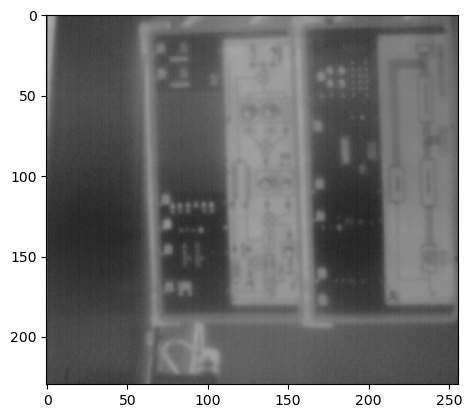

In [164]:
image = cv2.imread("images/film.png", cv2.IMREAD_GRAYSCALE)

image = image.astype(np.uint16)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

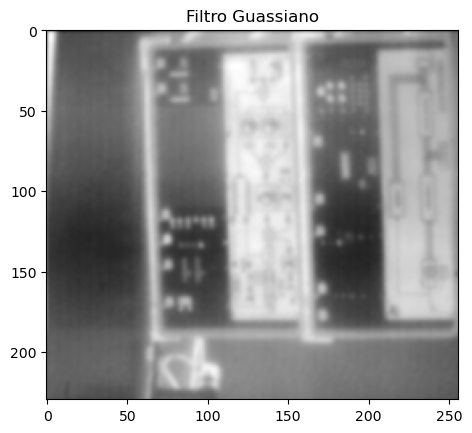

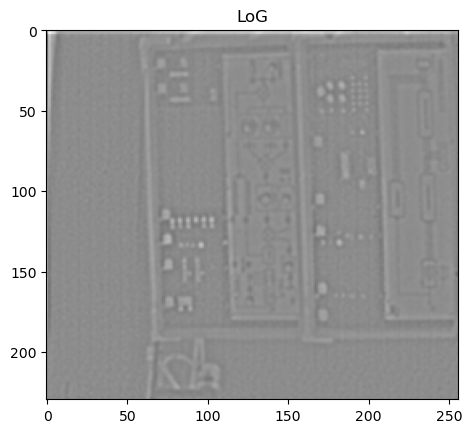

In [165]:
#Aplique un filtro gaussiano (con varianza igual a 1) y un filtro Laplaciano siguiendo los mismos pasos de los ejercicios previos. Visualice la imagen del LoG.
img_gaus = gaussian(image, sigma=1, preserve_range=True)

# Visualizar imagen
plt.imshow(img_gaus, cmap="gray")
plt.title("Filtro Guassiano")
plt.show()

img_l = laplace(img_gaus, ksize=3)

# Visualizar imagen
plt.imshow(img_l, cmap="gray")
plt.title("LoG")
plt.show()

-61.65012788943783 50.18474127116883


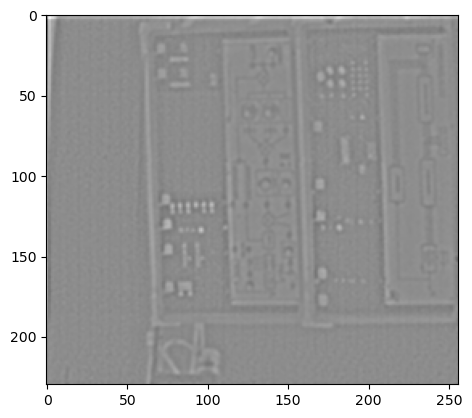

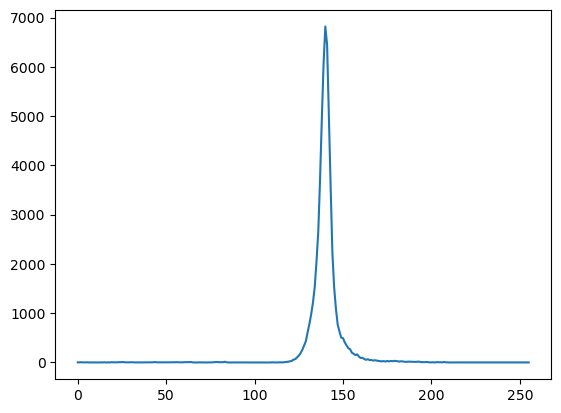

In [166]:
#Calibre el histograma de la imagen del LoG entre 0 y 255 y déjela de tipo UInt8.
print(img_l.min(), img_l.max())
#Calibracion del histograma
rescaled_img = exposure.rescale_intensity(img_l, in_range=(img_l.min(),img_l.max()), out_range=(0,255))

# Visualizar imagen
plt.imshow(rescaled_img, cmap="gray")
plt.show()

# Visualizar histograma
rescaled_img = rescaled_img.astype(np.uint8)
hist = cv2.calcHist([rescaled_img],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()


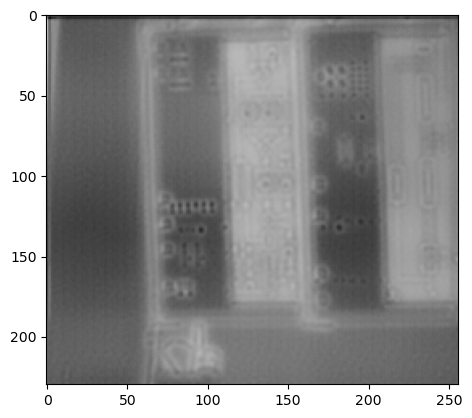

In [167]:
#Combine esta última imagen (la del LoG calibrada) con 60% de la imagen inicial. Esto quiere decir multiplicar la imagen original por el valor 0.6 y sumarla a la imagen invertida del LoG.

# 60 % de la imagen original
image_60 = (image * 0.6).astype(np.uint8)

# LoG invertido
log_inverted1 = 255 - rescaled_img

image_added = cv2.add(image_60, log_inverted1)

# Visualizar imagen
plt.imshow(image_added, cmap="gray")
plt.show()

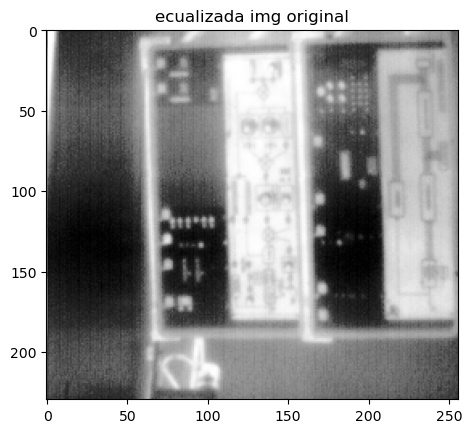

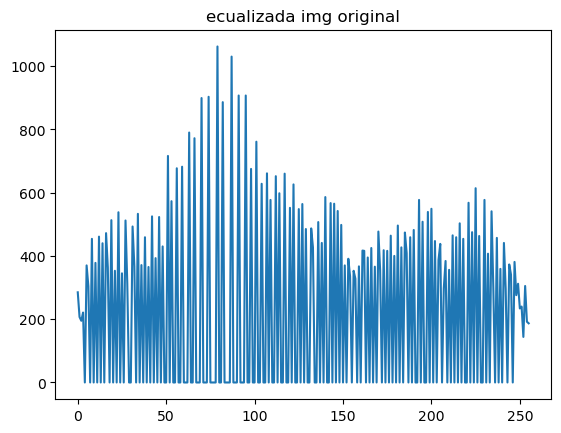

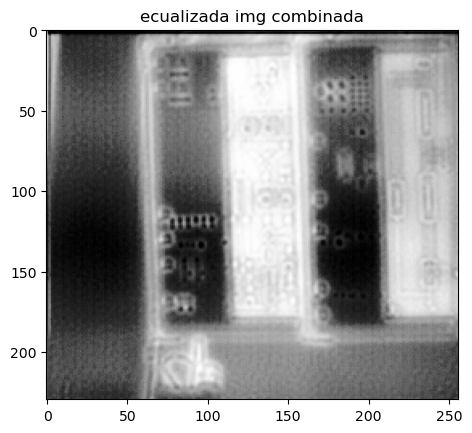

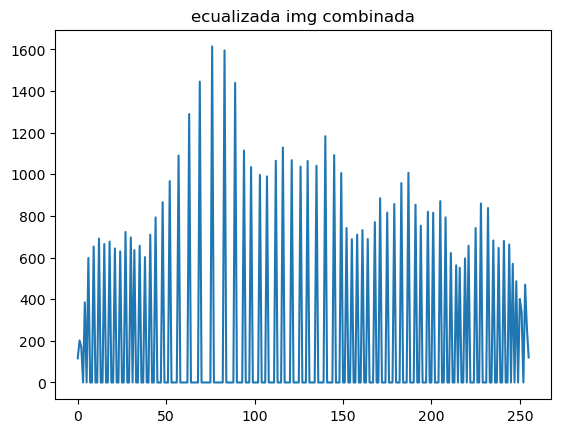

In [168]:
#Para acentuar el interés del procesamiento, efectúe una ecualización del histograma de la imagen original y de la imagen combinada. Visualice el resultado. 

# Ecualizar el histograma
image = image.astype(np.uint8)
imagen_equ = cv2.equalizeHist(image)

# Visualizar imagen
plt.imshow(imagen_equ, cmap="gray",  vmin=0, vmax=255)
plt.title("ecualizada img original")
plt.show()

# Visualizar histograma
hist = cv2.calcHist([imagen_equ],[0],None,[256],[0,256])
plt.plot(hist)
plt.title("ecualizada img original")
plt.show()

# Ecualizar el histograma
image_added = image_added.astype(np.uint8)
imagen_equ = cv2.equalizeHist(image_added)

# Visualizar imagen
plt.imshow(imagen_equ, cmap="gray",  vmin=0, vmax=255)
plt.title("ecualizada img combinada")
plt.show()

# Visualizar histograma
hist = cv2.calcHist([imagen_equ],[0],None,[256],[0,256])
plt.plot(hist)
plt.title("ecualizada img combinada")
plt.show()

La imagen combinada ecualizada se ve más borrosa y menos definida que la imagen original ecualizada. Aunque los bordes y estructuras principales siguen presentes, el proceso de combinación e inversión del LoG suaviza y difumina los detalles, haciendo que los contornos sean menos nítidos.
Esto ocurre porque el LoG invertido y sumado a la imagen original introduce un efecto de suavizado, que puede reducir el contraste y la claridad de los detalles.